Name: Christopher A. Lee\
Date: 04/21/2026\
Prof: Dr. Azarnoosh\
Course: Machine Learning for Data Analysis - ENBC 321

In [1]:
# Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

from keras.datasets import cifar10
from keras import layers, Sequential

In [2]:
# Set seed
random.seed(321)

In [3]:
# Import data
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

/Users/christopherlee/.pyenv/versions/3.13.13/lib/python3.13/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Training Shape:
(50000, 32, 32, 3)
Testing Shape:
(10000, 32, 32, 3)
[ 0  8 46 53 61 63 68 77 78 91]


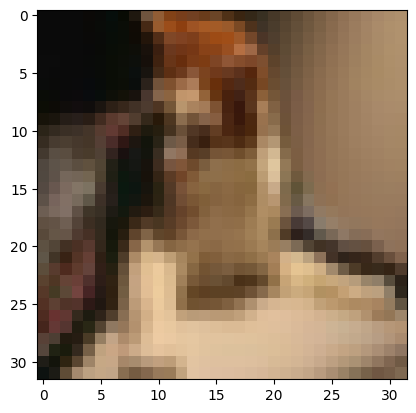

In [4]:
# Data exploration
print("Training Shape:")
print(x_train.shape)
print("Testing Shape:")
print(x_test.shape)

# First 10 cat image indices
cat_indices = np.where(y_test.flatten() == 3)[0]
print(cat_indices[:10])

# Plot Cat image
plt.imshow(x_test[cat_indices[4]])
plt.show()

# Normalize training and testing data
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Reshape data
x_train = x_train.reshape(-1, 32, 32, 3)
x_test = x_test.reshape(-1, 32, 32, 3)

In [5]:
# Create Convolutional Neural Network
model = Sequential((
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu'),
    layers.MaxPool2D(2, 2),
    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPool2D(2, 2),
    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(x_train, y_train, epochs=5, validation_split=0.1)

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.4246 - loss: 1.5826 - val_accuracy: 0.5286 - val_loss: 1.3141
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.5722 - loss: 1.2061 - val_accuracy: 0.5830 - val_loss: 1.1840
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.6243 - loss: 1.0618 - val_accuracy: 0.6270 - val_loss: 1.0650
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.6674 - loss: 0.9502 - val_accuracy: 0.6528 - val_loss: 1.0053
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.6882 - loss: 0.8891 - val_accuracy: 0.6790 - val_loss: 0.9158


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6763 - loss: 0.9360

Test Accuracy: 0.6762999892234802

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


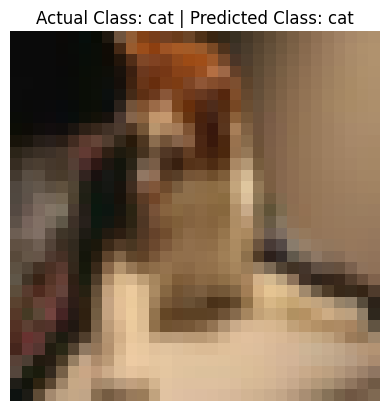

In [6]:
# Test Set Evaluation
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"\nTest Accuracy: {test_acc}\n")

# Names of each class
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer', 
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Model Prediction on chosen picture
img = x_test[cat_indices[4]]
img_batch = np.expand_dims(img, axis=0)

predicted_class = class_names[np.argmax(model.predict(img_batch))]
actual_class = 'cat'

plt.imshow(img)
plt.title(f"Actual Class: {actual_class} | Predicted Class: {predicted_class}")
plt.axis('off')
plt.show()